<a href="https://colab.research.google.com/github/leorfoletto/car_prediction/blob/main/Projeto_Final_Leonardo_Foletto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Final: **Previsão do preço de um carro**

## **Definição do escopo**

Quando pessoas buscam um carro para comprar, muitas vezes por falta de conhecimento sobre o assunto, acabam pagando um valor acima do preço justo para um veículo. A fim de evitar que o vendedor anuncie seu carro a um preço muito alto ou baixo, de forma que busque vender o veículo com mais facilidade e obter por ele um preço justo, nosso programa irá, a partir de uma base de dados fornecida, obter a previsão do preço de um veículo a partir de parâmetros fornecidos.

* Link da base de dados obtida:

https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

* Link da base de dados alterada em planilha:

https://docs.google.com/spreadsheets/d/1BMvWcGBK-Yza4sQJMQxMXp1uSFF92HHrD3nwqyoCcKc/export?format=csv


### Dicionário de Dados

A partir dos dados obtidos na planilha, é possível montar um dicionário de dados:

| Nome                  | Descrição                                     | Tipo     | Valores permitidos                                                                                                                                                                                                                                                               |
| --------------------- | --------------------------------------------- | -------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Fabricante            | Montadora de automóveis                       | category | Audi, BMW, Chevrolet, Datsun, Ferrair, Fiat, Ford, Honda, Hyundai, Isuzu, Jaguar, Jeep, Kia, Land Rover, Mahindra, Make, Maruti Suzuki, Maserati, Mercedes-Benz, MG, MINI, Mitsubishi, Nissan, Porsche, Renault, Rolls-Royce, Skoda, Ssangyoung, Tata, Toyota, Volkswagen, Volvo |
| Modelo                | Modelo do automóvel                           | object   | Modelos                                                                                                                                                                                                                                                                          |
| Preço                 | Preço do carro em Rupias indianas             | int      | 49000 a 35000000                                                                                                                                                                                                                                                                 |
| Ano                   | Ano do modelo                                 | int      | 1988 a 2022                                                                                                                                                                                                                                                                      |
| Kilometragem          | Kilometragem rodada                           | int      | 0 a 2000000                                                                                                                                                                                                                                                                      |
| Combustível           | Tipo de combustível do automóvel              | category | CNG, Diesel, Hybrid, LPG, Petrol, Petrol +CNG                                                                                                                                                                                                                                    |
| Transmissão           | Tipo de transmissão                           | category | Automatic, Manual                                                                                                                                                                                                                                                                |
| Localização           | Local onde se encontra o veículo              | category | Cidades indianas                                                                                                                                                                                                                                                                 |
| Cor                   | Cor do automóvel                              | category | Beige, Black, Blue, Bronze, Brown, Gold, Green, Grey, Maroon, Orange, Others, Purple, Red, Silver, White, Yellow                                                                                                                                                                 |
| Dono                  | É o (primeiro, segundo...) a ter o veículo    | category | First, Second, Third, UnRegistered Car                                                                                                                                                                                                                                           |
| Vendedor              | Se é vendido por uma pessoa ou corporativa    | category | Commercial Registration, Corporate , Individual                                                                                                                                                                                                                                  |
| Motor (cc)            | Cilindradas do motor (cc)                     | int      | 624 a 6592                                                                                                                                                                                                                                                                       |
| Trem de força         | Tipo de trem de força                         | category | AWD, FWD, RWD                                                                                                                                                                                                                                                                    |
| Comprimento           | Comprimento do automóvel em milímetros        | int      | 3099 a 5569                                                                                                                                                                                                                                                                      |
| Altura                | Altura do automóvel em milímetros             | int      | 1475 a 2220                                                                                                                                                                                                                                                                      |
| Largura               | Largura do automóvel em milímetros            | int      | 1213 a 1995                                                                                                                                                                                                                                                                      |
| Passageiros           | Quantos passageiros sentados comporta         | int      | 2 a 8                                                                                                                                                                                                                                                                            |
| Tanque                | Capacidade do tanque de combustível em litros | float    | 15 a 105                                                                                                                                                                                                                                                                         |
| Potência máxima (bhp) | Potência máxima do automóvel em bhp           | float    | 7 a 660                                                                                                                                                                                                                                                                          |
| Potência máxima (rpm) | Potência máxima do automóvel em rpm           | float    | 2910 a 8250                                                                                                                                                                                                                                                                      |
| Torque máximo (Nm)    | Torque máximo do automóvel em Nm              | float    | 8 a 7619                                                                                                                                                                                                                                                                         |
| Torque máximo (rpm)   | Torque máximo do automóvel em rpm             | float    | 150 a 5600                                                                                                                                                                                                                                                                       |

## **Preparação da base**

### Leitura da base

Inicialmente, vamos importar todas as bibliotecas que utilizaremos em nosso notebook.

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import math
import folium
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, RidgeCV, LassoCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

* Agora, vamos importar a planilha em formato csv contendo a base de dados, que foi anteriormente convertida em um arquivo "Google Drive", para o nosso notebook.
* Utilizaremos a biblioteca Pandas para a leitura do arquivo csv, e faremos as alterações necessárias, para ela se adequar ao nosso estudo.
* Para a leitura feita pelo pandas, iremos trocar os títulos de cada coluna para o português

In [ ]:
# Definição do número de casas decimais no pandas
pd.options.display.float_format = '{:,.2f}'.format

# Definição do número de casas decimais no numpy
np.set_printoptions(precision = 2)

# Ler o arquivo gravado em meu Google Drive

link = 'https://docs.google.com/spreadsheets/d/1BMvWcGBK-Yza4sQJMQxMXp1uSFF92HHrD3nwqyoCcKc/export?format=csv'
a = pd.read_csv(link, header=0, names=['Fabricante', 'Modelo', 'Preço', 'Ano', 'Kilometragem', 'Combustível', 'Transmissão', 'Localização', 'Cor', 'Dono', 'Vendedor', 'Motor (cc)', 'Potência máxima', 'Torque máximo', 'Trem de força', 'Comprimento', 'Altura', 'Largura', 'Passageiros', 'Tanque'])


### Manipulação da base

Com a planilha importada ao programa, é necessário realizar algumas mudanças em nossa base, para torná-la melhor para leitura. Inicialmente, vamos transformar os dados da coluna 'Motor (cc)', removendo a parte 'cc' dos dados, deixando os valores apenas numéricos. Assim, podemos transformar o seu tipo em 'int', que representa apenas números inteiros, facilitando a leitura do programa para essa coluna.

In [ ]:
a['Motor (cc)'] = a['Motor (cc)'].str.replace('cc', '', regex=False)
a['Motor (cc)'] = a['Motor (cc)'].astype(int)

Outra mudança a ser feita em nossa base de dados, é nas colunas Potência máxima e torque máximo, elas continham 2 tipos de dados ao todo (Ex.: 660 bhp @ 8000 rpm).
Para facilitar a leitura de nosso prorgama, vamos dividir essa coluna, que contém os 2 dados, em 2 colunas, cada uma contendo um tipo de dado apenas.

In [ ]:
a[['Potência máxima (bhp)', 'Potência máxima (rpm)']] = a['Potência máxima'].str.extract(r'(\d+) bhp @ (\d+) rpm')
del a['Potência máxima']
a[['Torque máximo (Nm)', 'Torque máximo (rpm)']] = a['Torque máximo'].str.extract(r'(\d+) Nm @ (\d+) rpm')
del a['Torque máximo']

Feita as alterações nas colunas, agora podemos trocar o tipo de dado das colunas, para facilitar a leitura de nosso programa.
* Para os dados numéricos inteiros, usaremos o tipo 'int'.
* Para os dados que são caracteres alfabéticos, mas que são finitos e podem ser categorizados, (Ex.: Existe uma diferença de categoria entre um carro da Fiat e um da Mercedes) usaremos o tipo 'category'
* Para dados numéricos que contenham casas decimais, usaremos o tipo 'float'.

In [ ]:
a['Fabricante']=a['Fabricante'].astype('category')
a['Passageiros']=a['Passageiros'].astype(int)
a['Combustível']=a['Combustível'].astype('category')
a['Transmissão']=a['Transmissão'].astype('category')
a['Localização']=a['Localização'].astype('category')
a['Cor']=a['Cor'].astype('category')
a['Dono']=a['Dono'].astype('category')
a['Vendedor']=a['Vendedor'].astype('category')
a['Trem de força']=a['Trem de força'].astype('category')
a['Potência máxima (bhp)']=a['Potência máxima (bhp)'].astype(float)
a['Potência máxima (rpm)']=a['Potência máxima (rpm)'].astype(float)
a['Torque máximo (Nm)']=a['Torque máximo (Nm)'].astype(float)
a['Torque máximo (rpm)']=a['Torque máximo (rpm)'].astype(float)
a['Comprimento']=a['Comprimento'].astype(int)
a['Largura']=a['Largura'].astype(int)
a['Altura']=a['Altura'].astype(int)

Para facilitar a leitura do programa, vamos manter apenas as colunas que podem ser categorizadas, ou numéricas, portanto, se torna necessária a exclusão da coluna 'Modelo', já que pelo grande número de modelos, que praticamente não se repetem ao longo da base, acaba dificultando a leitura do programa. Assim a coluna de 'Modelo' será excluída.

In [ ]:
del a['Modelo']

Para finalizar a manipulação de nossa base de dados, a fim de que fique perfeito para a leitura, removeremos os valores faltando que acabaram sendo gerados pela manipulação da divisão das colunas de Potência Máxima e Torque Máximo.

In [ ]:
a.dropna(inplace=True)

### Amostra da base

Feita as devidas correções,  temos a seguinte amostra de nossa base, com os 5 primeiros resultados.

In [ ]:
a.head()

,Fabricante,Preço,Ano,Kilometragem,Combustível,Transmissão,Localização,Cor,Dono,Vendedor,...,Trem de força,Comprimento,Altura,Largura,Passageiros,Tanque,Potência máxima (bhp),Potência máxima (rpm),Torque máximo (Nm),Torque máximo (rpm)
0,Renault,450000,2016,2000000,Diesel,Manual,Ranchi,White,First,Individual,...,FWD,4315,1822,1695,5,50.00,108.00,"3,900.00",248.00,"2,250.00"
1,Hyundai,925000,2018,925000,Diesel,Manual,Karnal,White,First,Individual,...,FWD,4375,1700,1475,5,43.00,126.00,"4,000.00",260.00,"1,900.00"
2,Hyundai,1240000,2018,440000,Diesel,Automatic,Delhi,Grey,First,Individual,...,FWD,4270,1780,1665,5,55.00,126.00,"4,000.00",260.00,"1,500.00"
3,Audi,1650000,2012,240000,Diesel,Automatic,Lucknow,White,First,Individual,...,AWD,4915,1874,1455,5,75.00,245.00,"4,000.00",500.00,"1,400.00"
4,Toyota,2750000,2017,219000,Diesel,Automatic,Jaipur,White,Second,Individual,...,AWD,4795,1855,1835,7,80.00,174.00,"3,400.00",450.00,"1,600.00"


## **Informações da Base**

### Informações gerais

Com uma amostra de nossa base, podemos mostrar as informações principais de nossa base

In [ ]:
a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1802 entries, 0 to 1873
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Fabricante             1802 non-null   category
 1   Preço                  1802 non-null   int64   
 2   Ano                    1802 non-null   int64   
 3   Kilometragem           1802 non-null   int64   
 4   Combustível            1802 non-null   category
 5   Transmissão            1802 non-null   category
 6   Localização            1802 non-null   category
 7   Cor                    1802 non-null   category
 8   Dono                   1802 non-null   category
 9   Vendedor               1802 non-null   category
 10  Motor (cc)             1802 non-null   int64   
 11  Trem de força          1802 non-null   category
 12  Comprimento            1802 non-null   int64   
 13  Altura                 1802 non-null   int64   
 14  Largura                1802 non-null   int64 

Vemos que ao todo, temos 1802 diferentes carros a serem analisados em nossa base, mostrando o tipo de dado de cada coluna, conforme alteramos acima.

### Descrição dos dados

Agora, podemos fazer uma análise estatística de nossa base de dados.
A partir dos dados numéricos fornecidos, podemos obter as médias, desvio padrão, valores máximos e mínimos, dentre outros parâmetros.

In [ ]:
a.describe()

,Preço,Ano,Kilometragem,Motor (cc),Comprimento,Altura,Largura,Passageiros,Tanque,Potência máxima (bhp),Potência máxima (rpm),Torque máximo (Nm),Torque máximo (rpm)
count,"1,802.00","1,802.00","1,802.00","1,802.00","1,802.00","1,802.00","1,802.00","1,802.00","1,802.00","1,802.00","1,802.00","1,802.00","1,802.00"
mean,"1,759,514.94","2,016.97","52,009.16","1,678.32","4,283.27","1,769.89","1,589.88",5.30,52.20,129.11,"4,823.09",314.02,"2,617.86"
std,"2,457,562.69",2.87,"59,309.51",630.26,434.20,131.58,134.22,0.81,15.03,63.96,"1,098.27",706.03,"1,207.09"
min,"141,000.00","1,988.00",0.00,793.00,"3,395.00","1,475.00","1,213.00",2.00,27.00,7.00,"2,910.00",8.00,150.00
25%,"525,000.00","2,015.00","28,000.00","1,197.00","3,985.00","1,695.00","1,485.00",5.00,42.00,83.00,"4,000.00",115.00,"1,600.00"
50%,"862,500.00","2,017.00","48,000.00","1,498.00","4,357.00","1,775.00","1,544.00",5.00,50.00,116.00,"4,200.00",204.00,"1,800.00"
75%,"1,950,000.00","2,019.00","69,500.00","1,995.00","4,620.00","1,831.00","1,671.00",5.00,60.00,170.00,"6,000.00",350.00,"4,000.00"
max,"35,000,000.00","2,022.00","2,000,000.00","6,592.00","5,569.00","2,220.00","1,995.00",8.00,105.00,660.00,"8,250.00","7,619.00","5,600.00"


Com a análise de dados, podemos fazer algumas observações:
* O desvio padrão da coluna de preço é muito alto, sendo bem maior que a média, além de apresentar valores muito acima dos demais (como 35000000,00).
* A grande maioria dos carros são dos últimos 10 anos, o que já era esperado.
* A Kilometragem apresenta um valor máximo muito alto de 2000000 Km rodados, o que é um pouco irreal.
* O comprimento, largura e altura apresentam valores esperados, próximos da realidade.
* Número de passageiros dentro do esperado.
* Capacidade do tanque também está dentro do esperado.
* Potência Máxima e Torque máximo apresentam valores corretos também, evidenciando que a divisão das colunas foi bem sucedida.


## **Análise exploratória dos dados**

Feita manipulação e descrição dos dados de nossa base, podemos fazer uma análise exploratória dos dados, definindo perguntas a serem respondidas.
A principal pergunta a ser respondida é qual o preço esperado ao carro, dado os parâmetros apresentados ('Fabricante', 'Modelo', 'Preço', 'Ano', 'Kilometragem', 'Combustível', 'Transmissão', 'Localização', 'Cor', 'Dono', 'Vendedor', 'Motor (cc)', 'Potência máxima', 'Torque máximo', 'Trem de força', 'Comprimento', 'Altura', 'Largura', 'Passageiros', 'Tanque')

Além disso, iremos realizar uma limpeza em nossa base de dados, excluindo outliers e variáveis que dificultam o desempenho de um modelo de machine learning.

Para isso, vamos elencar perguntas secundárias que podem nos ajudar a chegar nessa resposta


### Pergunta 1: Como é a distribuição do preço numéricos?


Para isso, vamos apresentar um boxplot de cada parâmetro numérico para avaliar sua distribuição.

<Axes: ylabel='Preço'>

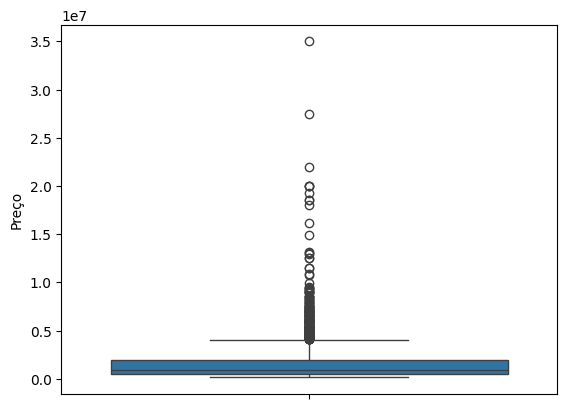

In [ ]:
sns.boxplot(data=a['Preço'])

Vemos que a distribuição do preço é bem peculiar. Vale ressaltar que a escala está em ₹ 10.000.000,00. Vemos que a maioria esmagadora dos preços estão entre 5 MI ou menos, apresentando alguns valores discrepantes acima do limite superior do boxplot.
Vemos também que existem valores muito descrepantes dos demais, como no caso de um carro de ₹ 35.000.000,00 (Ferrari 488 GTB) e um de ₹ 27.500.000 (Land Rover	Range Rover 3.0 V6 Diesel Vogue LWB).

Para se ter uma visão melhor da distribuição, vamos restringir melhor o nosso boxplot, de forma a ter uma visão ampliada.

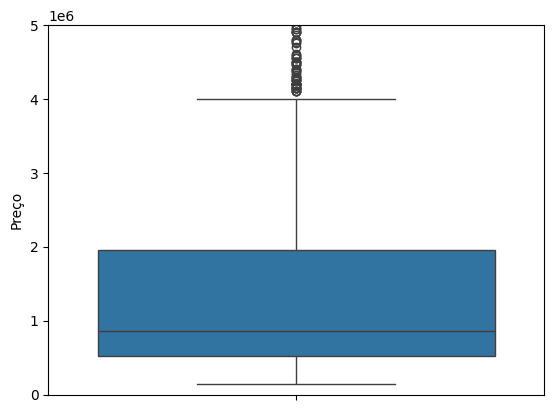

In [ ]:
sns.boxplot(data=a['Preço'])
plt.ylim(0, 5000000)
plt.show()

Com uma visão mais ampliada, podemos concluir que 75% dos carros apresentam preço inferior a ₹ 2.000.000,00 de Rupias Indianas, e que acima de ₹ 4.000.000,00 os preços são considerados outliers.

No histograma abaixo, fica bem visível como a distribuição do preço é bem desigual, com mais de 50% dos carros abaixo de ₹ 1.000.00,00

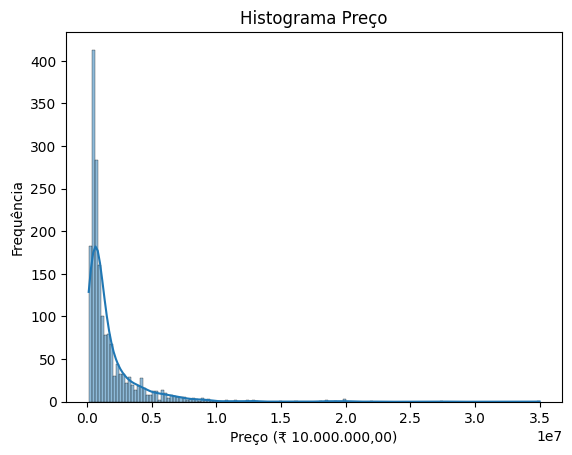

In [ ]:
sns.histplot(a['Preço'], kde=True)
plt.xlabel('Preço (₹ 10.000.000,00)')
plt.ylabel('Frequência')
plt.title('Histograma Preço')
plt.show()

### Pergunta 2: Qual o parâmetro numérico que apresenta maior correlação com o preço?


Para isso, vamos estabelecer uma matriz de correlação entre os parâmetros numéricos de nossa base de dados

Primeiramente, vamos separar as colunas com valores numéricos das colunas com valores categóricos, para que a análise seja feita separadamente.

In [ ]:
a_num = a.select_dtypes(include=['int64', 'float64'])
a_cat = a.select_dtypes(include=['category'])

Feita essa separação, podemos analisar uma matriz de correlação, utilizando o gráfico do tipo "Clustermap" da biblioteca seaborn.

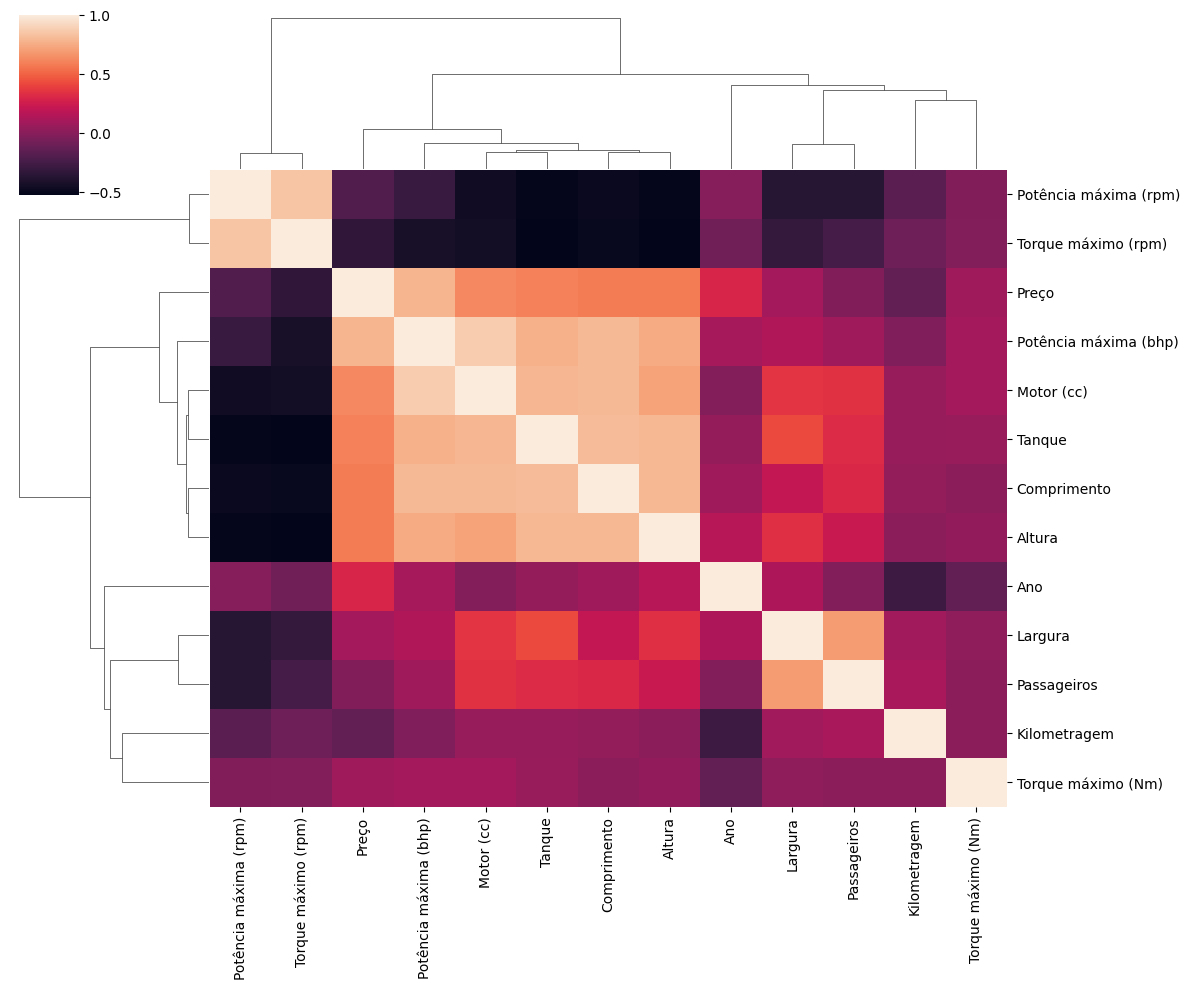

In [ ]:
Matriz = a_num.corr()
sns.clustermap(Matriz, pivot_kws=None, method='average', metric='euclidean', z_score=None, standard_scale=None, figsize=(12, 10), cbar_kws=None, row_cluster=True, col_cluster=True, row_linkage=None, col_linkage=None, row_colors=None, col_colors=None, mask=None, dendrogram_ratio=0.2, colors_ratio=0.03, cbar_pos=(0.02, 0.8, 0.05, 0.18), tree_kws=None)
plt.show()

Vemos que nesse caso, a potência máxima (bhp) apresenta maior correlação com o preço do carro, o que faz sentido, visto que um carro com maior potência tende a ter melhor desempenho e aceleração, tornando-o mais caro.

Além disso podemos tirar outras conclusões:
* Preço e Kilometragem apresentam correlação negativa (-0,14). Isso faz sentido, visto que carros mais rodados tendem a ter preços mais baixos.
* Comprimento e Altura apresentam uma boa correlação (0,80). Logo, carros mais longos tendem a ser mais altos, o que faz total sentido na realidade.
* Tanque e Altura ou Comprimento apresentam forte correlação. Isso faz sentido visto que carros com maiores dimensões tendem a apresentar maior espaço para comportar um tanque maior.
*  A maioria dos parâmetros com relação a kilometragem e ano, apresentm correlação muito próxima de 0, ou seja, tais aspectos não apresentam, na maioria dos casos, influência em tais parâmetros.

Feita a análise, vamos analisar mais a fundo agora a correlação entre a potência máxima e o preço, com um gráfico de dispersão, auxiliado por uma regressão linear

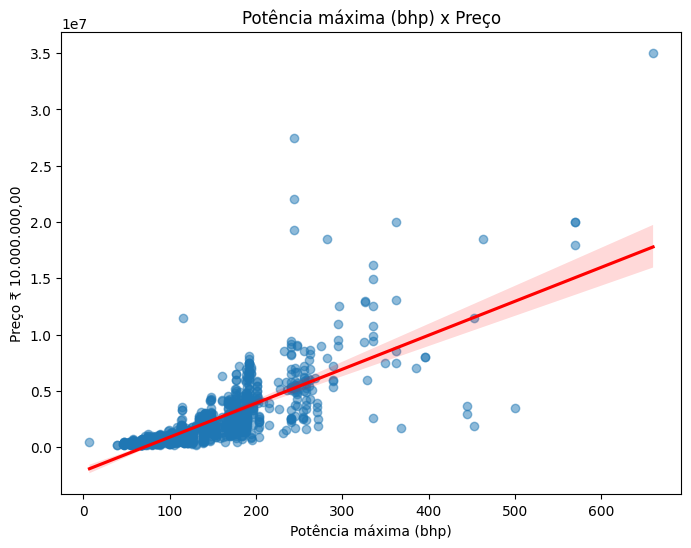

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(x=a["Potência máxima (bhp)"], y=a["Preço"], line_kws={"color": "r"}, scatter_kws={"alpha": 0.5}, ax=ax)
plt.xlabel('Potência máxima (bhp)')
plt.ylabel('Preço ₹ 10.000.000,00')
plt.title('Potência máxima (bhp) x Preço')
plt.show()

Vemos que a distribuição apresenta uma tendência a aumentar o preço, conforme aumenta a potência máxima (bhp). Isso fica claro quando vemos que os carros mais caros apresentam potência máxima (bhp) pelo menos superior a 200, enquanto grande parte, se não a maioria dos carros mais baratos apresentam potência máxima (bhp) próxima ou inferior a 200.

Além do mais, a partir da matriz de correlações, foram possíveis interpretar resultados que de certa forma causaram estranhamento, pelo fato de não ser o esperado. O primeiro deles é a correlação negativa entre o ano do carro e a kilometragem. Inicialmente isso não faz muito sentido, visto que carros antigos tendem a ser mais rodados do que carros novos. Para isso, vamos analisar a correlação entre Ano e a Kilometragem média em cada ano, a partir de um gráfico de colunas.

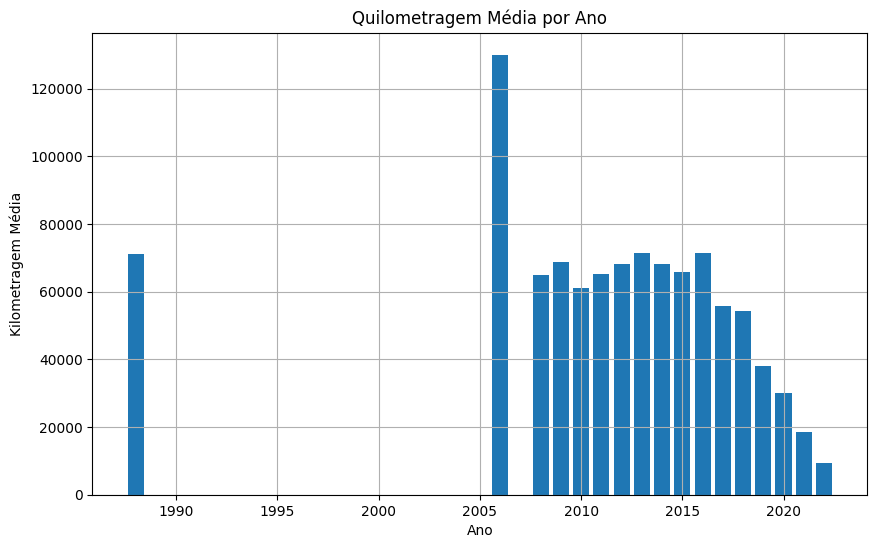

In [ ]:
media_kilometragem = a.groupby('Ano')['Kilometragem'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 6))
plt.bar(media_kilometragem['Ano'], media_kilometragem['Kilometragem'])
plt.xlabel('Ano')
plt.ylabel('Kilometragem Média')
plt.title('Quilometragem Média por Ano')
plt.grid(True)
plt.show()

Feita essa análise, podemos perceber que existem carros bem antigos, antes de 1990, que apresentam pouca kilometragem com relação a sua idade. Isso provavelmente se deve ao fato do carro ser uma relíquia, e não um carro do dia a dia, justificando o fato dele não ter tanta kilometragem. Fora isso, vemos que entre os anos de 2008 e 2016, a kilometragem média dos carros é semelhante, não apresentando muita variação entre os anos, o que de certa forma é surpreendente, já que o esperado é que os carros apresentem maior kilometragem média a medida que são mais antigos, porém, de 2016 até os dias de hoje, vemos que os carros apresentam menor kilometragem a medida que são mais novos.

Agora vamos analisar mais a fundo esses carros mais antigos, para ver qual a influência deles na base, para ver se podem ou não ser considerados outliers.

In [ ]:
a_old = a[a['Ano'] < 1990]
print(a_old)

        Fabricante    Preço   Ano  Kilometragem Combustível Transmissão  \
470  Mercedes-Benz  1300000  1988         71000      Petrol   Automatic   

    Localização  Cor   Dono    Vendedor  ...  Trem de força Comprimento  \
470    Dehradun  Red  Third  Individual  ...            RWD        5063   

     Altura  Largura  Passageiros  Tanque  Potência máxima (bhp)  \
470    1860     1494            5   80.00                 181.00   

     Potência máxima (rpm)  Torque máximo (Nm)  Torque máximo (rpm)  
470               5,500.00              300.00             1,200.00  

[1 rows x 21 columns]


Vemos na realidade que há apenas um único carro antes de 1990, que é uma Mercedes E-Class E 200 Avantgarde. Como era de se esperar, esse carro não é usual para o dia a dia, normalmente, faz parte de coleções ou algo do tipo, isso explica o fato dele ser tão antigo e ao mesmo tempo ter uma kilometragem "comum" para essa base.

Por se tratar de uma exeção a regra, vamos remover essa ocorrência.

In [ ]:
a = a[a['Ano'] >= 1990]

Outro fato que chamou a atenção, foi que Potência máxima bhp e rpm apresentam correlação negativa. Vamos analisar mais à fundo, a partir de um gráfico de dispersão com regressão linear.

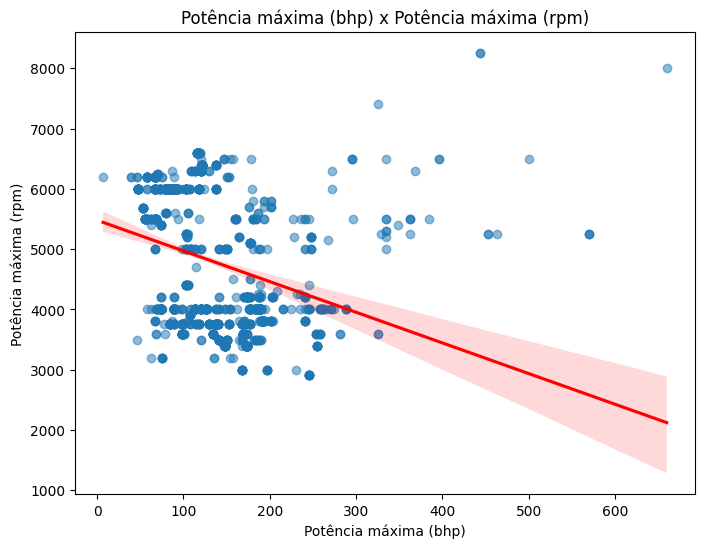

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.regplot(x=a["Potência máxima (bhp)"], y=a["Potência máxima (rpm)"], line_kws={"color": "r"}, scatter_kws={"alpha": 0.5}, ax=ax)
plt.xlabel('Potência máxima (bhp)')
plt.ylabel('Potência máxima (rpm)')
plt.title('Potência máxima (bhp) x Potência máxima (rpm)')
plt.show()

Vemos que a distribuição é de certa forma aleatória. Pesquisando mais à fundo, a respeito das duas propriedades de um carro, é possível concluir que a relação entre ambos os parâmetros não se dá de maneira direta, já que ambos dependem de outros fatores, como a eficiência e design do motor por exemplo, que não são medidos pelo nosso dataframe.

### Pergunta 3: Qual a distribuição de parâmetros categóricos?

Para determinar qual parâmetro categórico apresenta maior influência no preço, vamos montar gráficos de colunas, para identificar A distribuição dos valores de cada categoria.

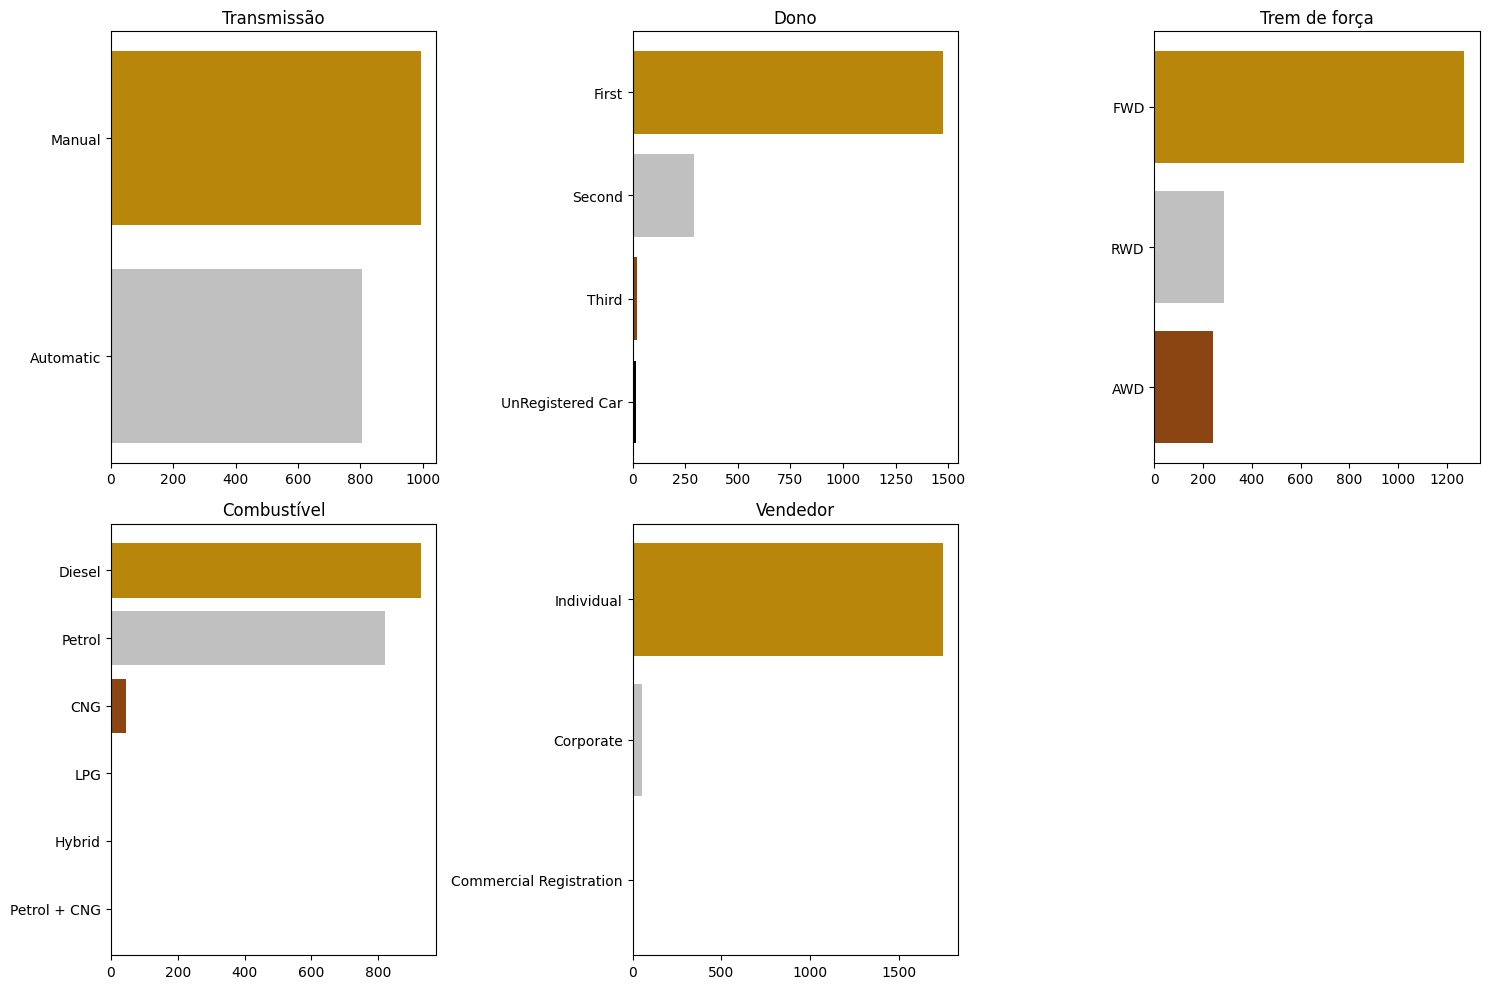

In [ ]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

transmissao_freq = a['Transmissão'].value_counts(ascending = True)
ax[0, 0].barh(transmissao_freq.index, transmissao_freq.values, color=['silver', 'darkgoldenrod'])
ax[0, 0].set_title('Transmissão')

dono_freq = a['Dono'].value_counts(ascending = True)
ax[0, 1].barh(dono_freq.index, dono_freq.values, color=['black', 'saddlebrown','silver', 'darkgoldenrod'])
ax[0, 1].set_title('Dono')

combustivel_freq = a['Combustível'].value_counts(ascending = True)
ax[1, 0].barh(combustivel_freq.index, combustivel_freq.values, color=['black', 'black','black','saddlebrown','silver', 'darkgoldenrod'])
ax[1, 0].set_title('Combustível')

vendedor_freq = a['Vendedor'].value_counts(ascending = True)
ax[1, 1].barh(vendedor_freq.index, vendedor_freq.values, color=['saddlebrown','silver', 'darkgoldenrod'])
ax[1, 1].set_title('Vendedor')

trem_de_forca_freq = a['Trem de força'].value_counts(ascending = True)
ax[0, 2].barh(trem_de_forca_freq.index, trem_de_forca_freq.values, color=['saddlebrown','silver', 'darkgoldenrod'])
ax[0, 2].set_title('Trem de força')

ax[1,2].set_visible(False)
plt.tight_layout()
plt.show()

* A maior parte dos carros é vendido por indivíduos
* A maior parte dos carros apresenta Trem de Força FWD
* A maior parte dos carros está em seu primeiro dono
* A maior parte dos carros apresenta Diesel comocombustível, porém um número próximo de automóveis apresenta Petróleo (Gasolina) como combustível
* A maioria dos carros é manual, porém o número de carros automáticos é muito próximo também.


Para ter uma limpeza maior em nossa base de dados, vamos excluir os parâmetros Commercial Registration, Petrol + CNG e Unregistred Car

In [ ]:
a = a[a['Vendedor'] != 'Commercial Registration']
a = a[a['Combustível'] != 'Petrol + CNG']
a = a[a['Dono'] != 'UnRegistered Car']

Agora vamos incluir em análise individualizada a cor.

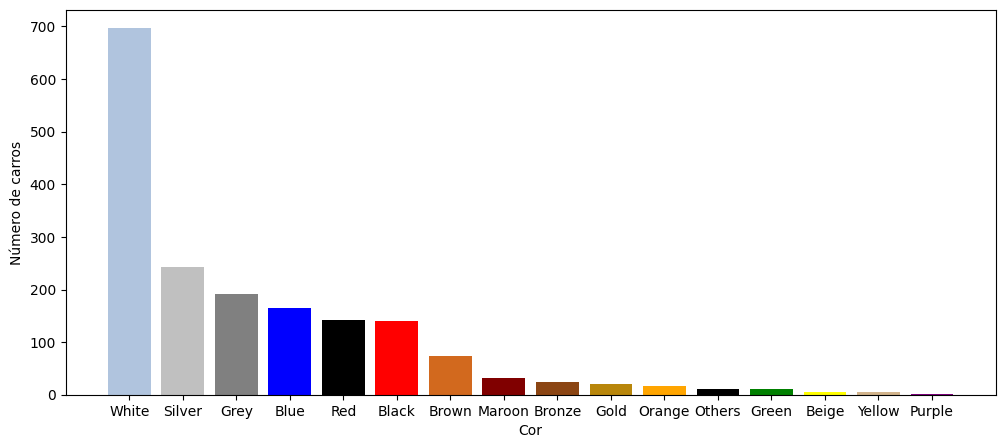

In [ ]:
cor_freq = a['Cor'].value_counts()
plt.figure(figsize=(12, 5))
plt.bar(cor_freq.index, cor_freq.values, color=['lightsteelblue', "silver", 'grey', 'blue', 'black', 'red','chocolate', 'maroon', 'saddlebrown', 'darkgoldenrod', 'orange', 'black', 'green', 'yellow', 'tan', 'purple'])
plt.xlabel('Cor')
plt.ylabel('Número de carros')
plt.show()

Vemos que a cor mais comum nesse caso é Branco, com a grande maioria dos carros sendo dessa cor

Agora, vamos avaliar a distribuição de carros por fabricante, analisando através de um gráfico de colunas, e de uma tabela, contendo o percentual de cada fabricante na base como um todo.

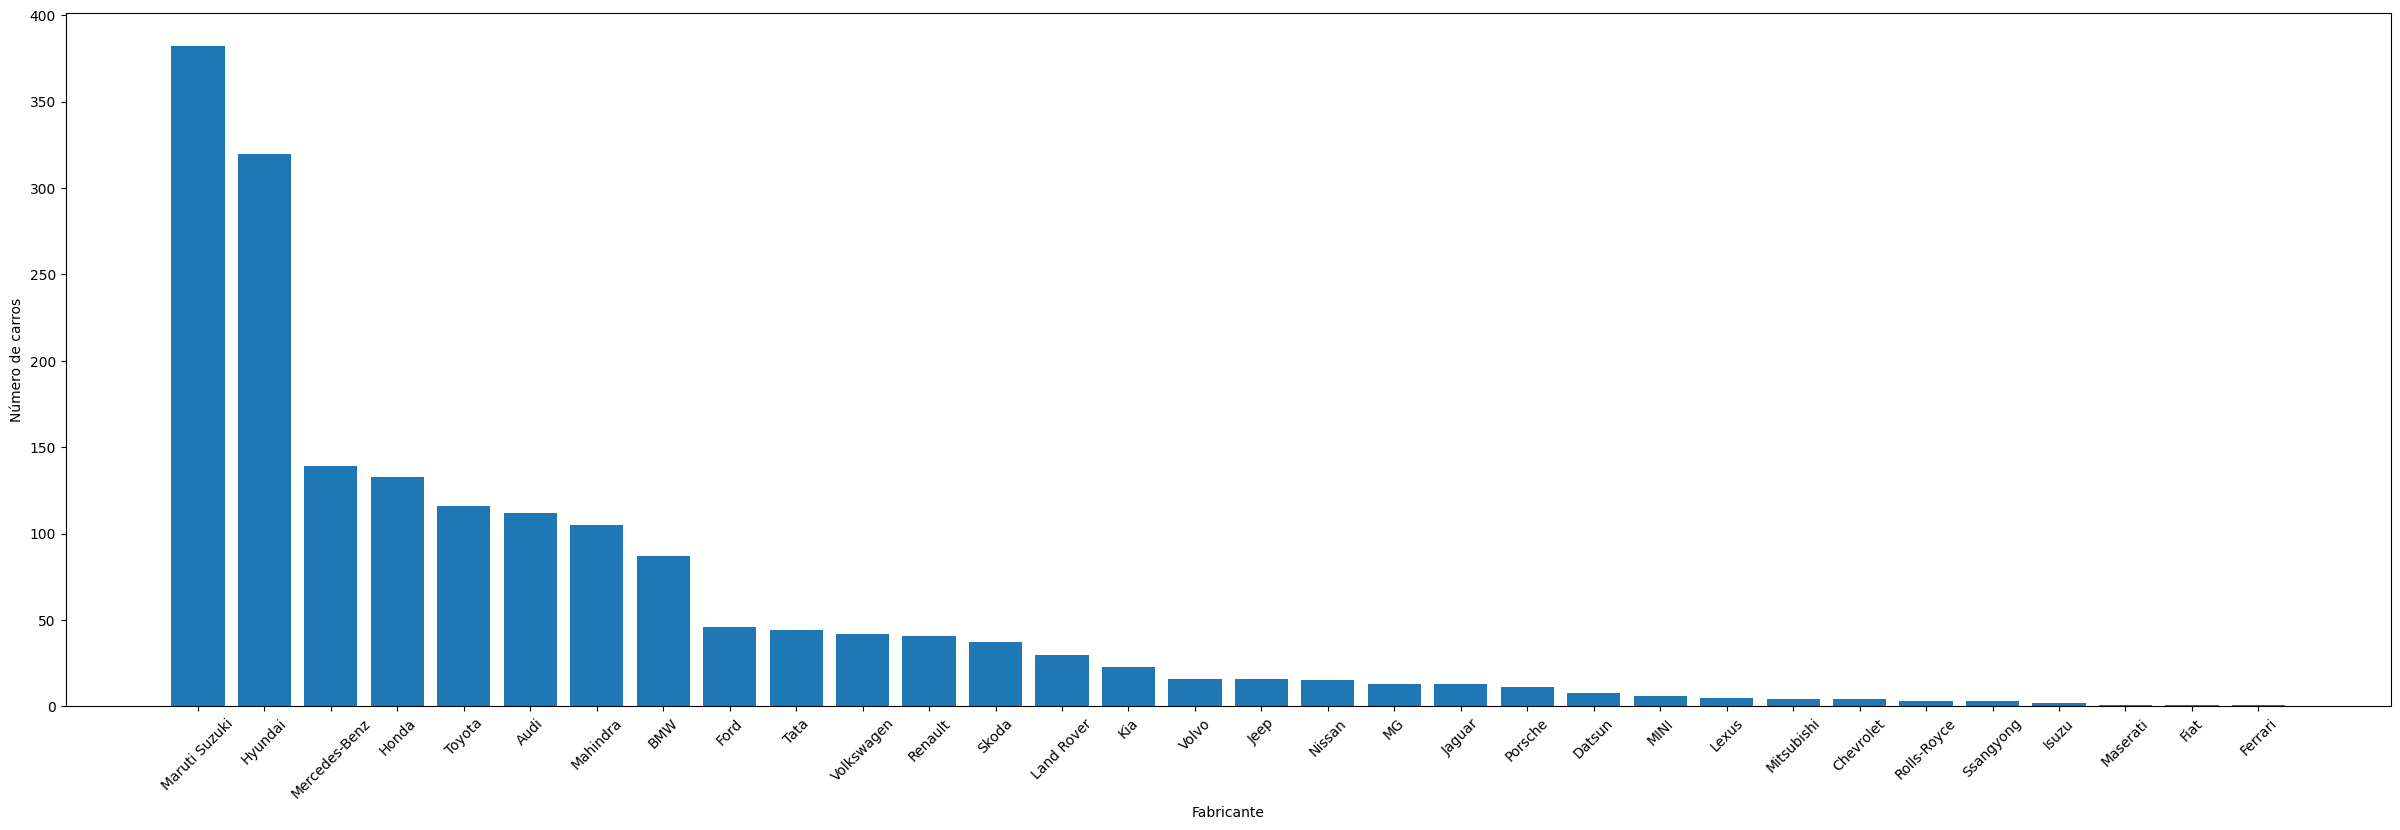

In [ ]:
fab_freq = a['Fabricante'].value_counts()
plt.figure(figsize=(30, 9))
plt.bar(fab_freq.index, fab_freq.values)
plt.xlabel('Fabricante')
plt.ylabel('Número de carros')
plt.xticks(rotation=45)
plt.show()

In [ ]:
fab_freq = a['Fabricante'].value_counts()
top_10 = fab_freq.sort_values(ascending=False)
top_10_freq = top_10.reset_index()
top_10_freq.columns = ['Fabricante', 'Frequência']
top_10_freq['      %'] = (top_10_freq['Frequência'] / fab_freq.sum()) * 100

print(top_10_freq)

       Fabricante  Frequência        %
0   Maruti Suzuki         382    21.47
1         Hyundai         320    17.99
2   Mercedes-Benz         139     7.81
3           Honda         133     7.48
4          Toyota         116     6.52
5            Audi         112     6.30
6        Mahindra         105     5.90
7             BMW          87     4.89
8            Ford          46     2.59
9            Tata          44     2.47
10     Volkswagen          42     2.36
11        Renault          41     2.30
12          Skoda          37     2.08
13     Land Rover          30     1.69
14            Kia          23     1.29
15           Jeep          16     0.90
16          Volvo          16     0.90
17         Nissan          15     0.84
18             MG          13     0.73
19         Jaguar          13     0.73
20        Porsche          11     0.62
21         Datsun           8     0.45
22           MINI           6     0.34
23          Lexus           5     0.28
24     Mitsubishi        

A maioria dos carros nesse caso, é da Maruti Suzuki, seguido por Hyundai, como as duas principais fabricantes de nossa base com uma certa folga para as demais, representando as duas somadas, quase 40% de todos os carro da base, o que é bem expressivo.

Para identificar quais as localizações mais frequentes, elencamos em uma tabela, o "Top 10" de cidades mais frequêntes. Além disso, incluímos as coordenadas de cada uma das cidades no dataframe, para que posteriormente possa ser feita uma análise da distribuição espacial dos carros em um mapa da Índia.

In [ ]:
loc_freq = a['Localização'].value_counts()
top_10 = loc_freq.sort_values(ascending=False)
top_10_freq = top_10.reset_index().head(10)
top_10_freq.columns = ['loc', 'freq']
top_10_freq['      %'] = (top_10_freq['freq'] / loc_freq.sum()) * 100
latitudes = [19.0760, 28.7041, 12.9716, 18.5204, 17.3850, 23.0225, 26.8467, 13.0827, 22.5726, 25.5941,
             30.9010, 26.4499, 30.7046, 26.9124, 28.4595, 28.4089, 30.7333, 30.3165, 23.3441, 11.0168,
             25.3176, 31.3260, 21.2514, 19.2183, 19.0330, 27.1767, 28.5355, 30.6456, 29.6857, 21.1702,
             30.3782, 22.8046, 20.0110, 13.3409, 28.9845, 23.2599, 12.2958, 22.7196, 26.1445, 30.6942,
             19.8762, 31.6340, 12.9141, 22.3072, 15.2993, 25.4358, 30.1290, 29.0050, 25.1458, 20.2961,
             17.9784, 21.1458, 11.6643, 28.6692, 15.4589, 24.4855, 8.8932, 30.7455, 22.7505, 22.3072,
             25.2138, 9.9312, 29.8543, 26.1209, 29.2206, 25.7771, 17.4399, 25.8617, 18.6298, 28.8955,
             12.9141, 26.7769, 20.6335, 26.7606, 18.9894]

longitudes = [72.8777, 77.1025, 77.5946, 73.8567, 78.4867, 72.5714, 80.9462, 80.2707, 88.3639, 85.1376,
              75.8573, 80.3319, 76.7179, 75.7873, 77.0266, 77.3178, 76.7794, 78.0322, 85.3096, 76.9558,
              82.9739, 75.5762, 81.6296, 72.9781, 73.0297, 78.0081, 77.3910, 76.8230, 76.9905, 72.8311,
              76.7970, 86.2029, 73.7868, 74.7463, 77.7064, 77.4126, 76.6394, 75.8577, 91.7362, 76.8640,
              75.3433, 74.8723, 74.8560, 73.1812, 73.0379, 81.8463, 77.2938, 79.4041, 82.5653, 85.8245,
              79.5952, 79.0882, 78.1310, 77.4538, 75.9772, 86.6977, 76.6141, 76.6853, 76.9064, 76.2676,
              76.7740, 76.2550, 81.2849, 79.9050, 83.7431, 73.2874, 78.0373, 79.3527, 74.7363, 75.0142,
              72.9933, 83.3430, 85.1540, 83.3010, 85.8241]
top_10_freq['lat'] = latitudes[:len(top_10_freq)]
top_10_freq['lon'] = longitudes[:len(top_10_freq)]

print(top_10_freq)

         loc  freq        %   lat   lon
0     Mumbai   290    16.30 19.08 72.88
1      Delhi   275    15.46 28.70 77.10
2  Bangalore   123     6.91 12.97 77.59
3       Pune   116     6.52 18.52 73.86
4  Hyderabad    96     5.40 17.39 78.49
5    Lucknow    66     3.71 23.02 72.57
6  Ahmedabad    64     3.60 26.85 80.95
7    Chennai    58     3.26 13.08 80.27
8    Kolkata    55     3.09 22.57 88.36
9      Patna    45     2.53 25.59 85.14


Visto o top 10 das cidades mais frequentes, para facilitar a visualização e compreeensão, vamos separar em um mapa da Índia, a frequência de carro por cidade:

In [ ]:
m = folium.Map(location=[20,80], tiles="OpenStreetMap", zoom_start=5)
for loc in top_10_freq.itertuples():
    local_deformation = math.cos(loc.lat * math.pi / 180)
    folium.Circle(
        location=[loc.lat, loc.lon],
        popup='%s (%.1f)' % (loc.loc, loc.freq),
        radius=loc.freq * 800 * local_deformation,
        color='crimson',
        fill=True,
        fill_color='crimson'
    ).add_to(m)

m

Vemos que são mais frequentes os carros nas regiões de Mumbai e Nova Delhi, o que faz sentido já que são as duas maiores cidades indianas.

### Pergunta 4: Qual a influência do fabricante, tipo de combustível, transmissão e trem de força no preço?

Para isso, vamos avaliar a relação entre cada categoria e o preço do carro. Primeiramente vamos começar analisando o fabricante, a partir de uma tabela que relaciona o preço médio por fabricante.

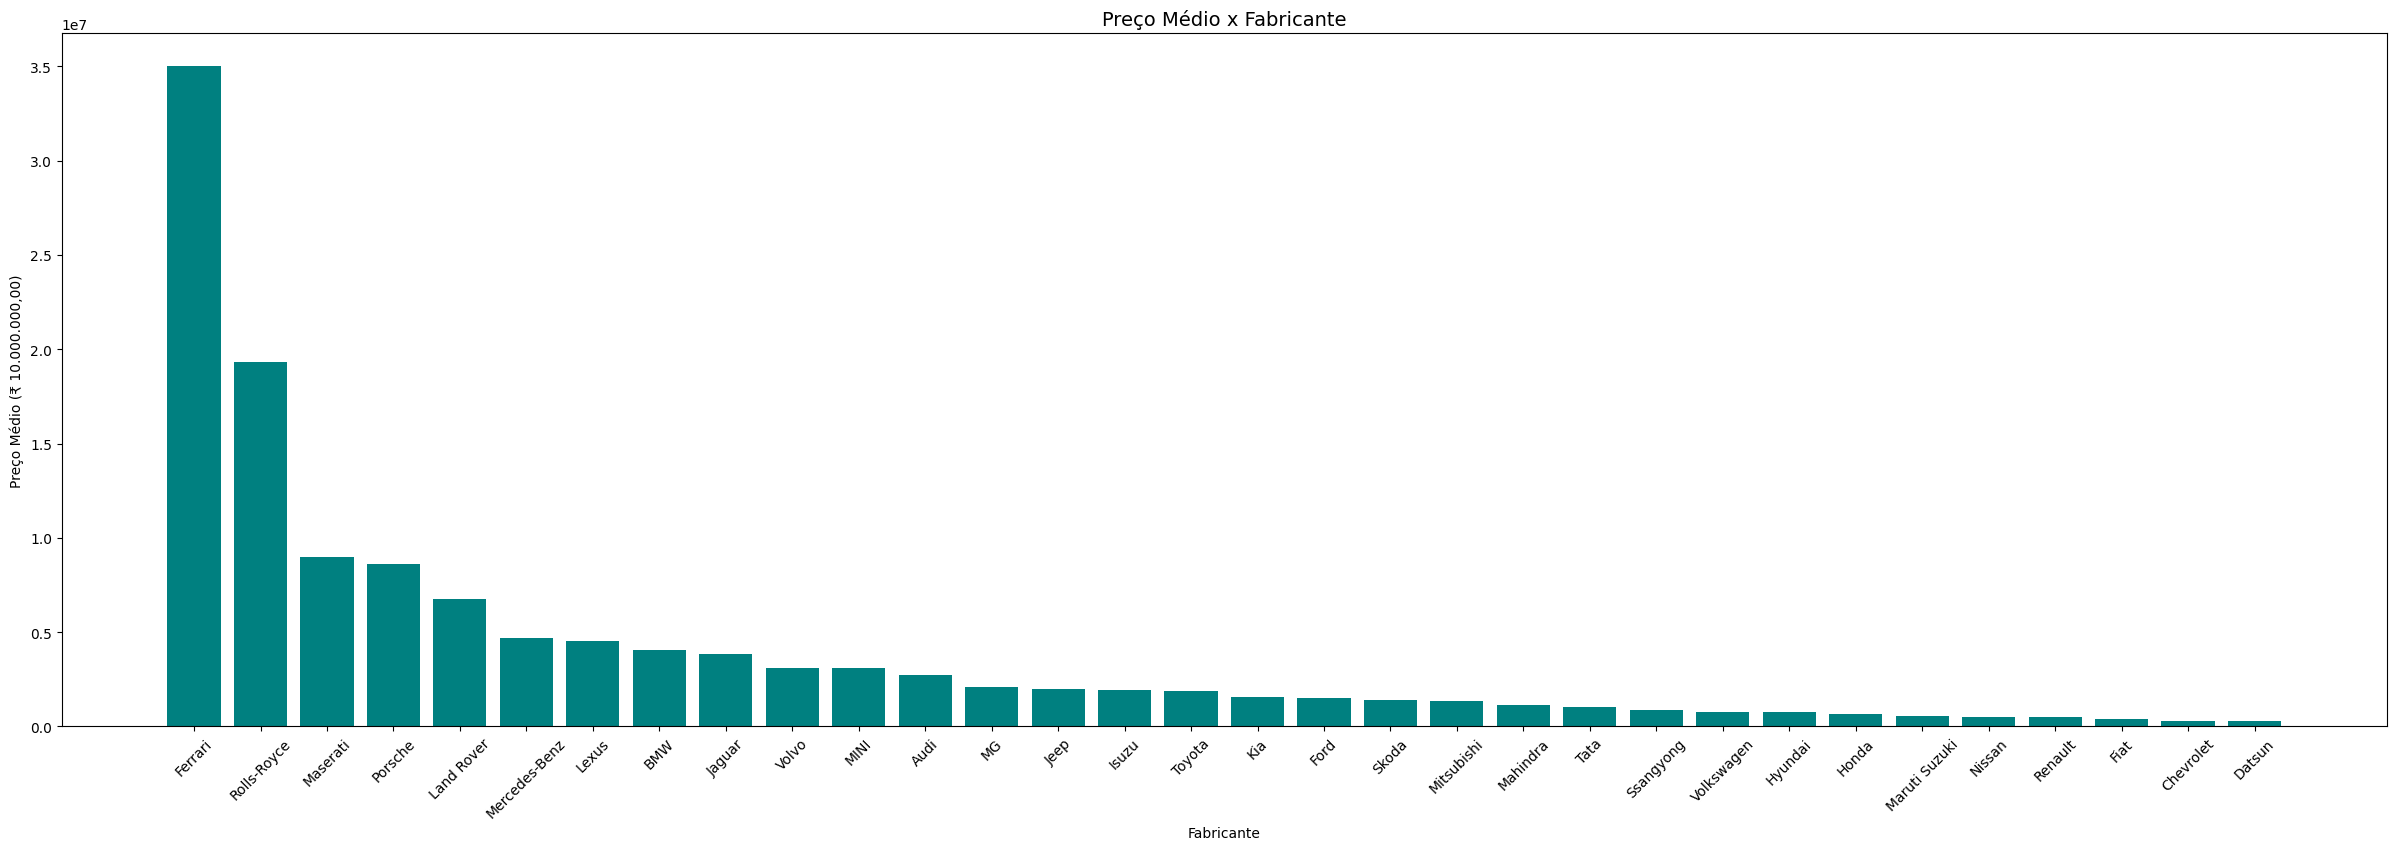

In [ ]:
# Definindo o preço médio de cada fabricante

preco_por_fabricante = a.groupby('Fabricante')['Preço'].mean().reset_index()
preco_por_fabricante.columns = ['Fabricante', 'Preço Médio']
preco_por_fabricante = preco_por_fabricante.sort_values(by='Preço Médio', ascending=False)

# Definindo o gráfico

plt.figure(figsize=(30, 9))
plt.bar(preco_por_fabricante['Fabricante'], preco_por_fabricante['Preço Médio'], color="teal")
plt.xlabel('Fabricante')
plt.ylabel('Preço Médio (₹ 10.000.000,00)')
plt.title('Preço Médio x Fabricante', size=14)
plt.xticks(rotation=45)
plt.show()

Vemos que a Ferrari lidera esse quesito, o que faz sentido, visto que a Ferrari apresenta apenas um carro em nossa base, que é justamente o mais caro, custando ₹ 35.000.000,00.

Agora, para uma compreensão melhor da distribuição do preço para cada fabricante, será feita uma análise estatística, de como é a distribuição do preço para cada categoria.

In [ ]:
a.groupby('Fabricante')['Preço'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Fabricante,,,,,,,,
Ferrari,1.00,"35,000,000.00",NaN,"35,000,000.00","35,000,000.00","35,000,000.00","35,000,000.00","35,000,000.00"
Rolls-Royce,3.00,"19,333,333.33","1,154,700.54","18,000,000.00","19,000,000.00","20,000,000.00","20,000,000.00","20,000,000.00"
Maserati,1.00,"9,000,000.00",NaN,"9,000,000.00","9,000,000.00","9,000,000.00","9,000,000.00","9,000,000.00"
Porsche,11.00,"8,609,090.91","3,365,473.09","3,500,000.00","6,425,000.00","9,000,000.00","9,400,000.00","16,200,000.00"
Land Rover,30.00,"6,769,600.00","5,942,368.79","2,150,000.00","3,650,000.00","5,025,000.00","6,500,000.00","27,500,000.00"
Mercedes-Benz,139.00,"4,677,856.10","3,135,484.39","850,000.00","2,400,000.00","4,150,000.00","6,400,000.00","20,000,000.00"
Lexus,5.00,"4,530,000.00","491,617.23","3,900,000.00","4,375,000.00","4,375,000.00","4,800,000.00","5,200,000.00"
BMW,87.00,"4,074,609.18","2,032,720.96","1,090,000.00","2,670,000.00","3,800,000.00","5,000,000.00","12,500,000.00"
Jaguar,13.00,"3,840,307.69","975,342.02","2,550,000.00","3,150,000.00","3,750,000.00","4,325,000.00","5,800,000.00"


Também é possível concluir que a Rolls-Royce também apresenta um alto preço por carro.

Já líderes em quantidade de modelo como Maruti Suzuki e Hyundai apresentam preço por carro bem mais em conta, evidenciando que elas fabricam modelos mais populares.

Agora vamos fazer a avaliação semelhante à feita para o fabricante, com relação ao tipo de combustível e o preço médio do veículo.

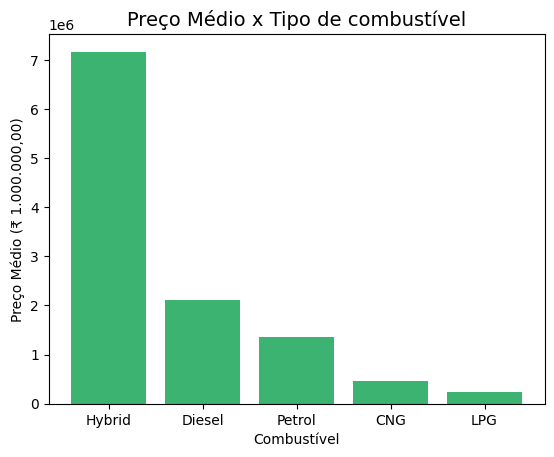

In [ ]:
# Definindo o preço médio de cada tipo de combustível

preco_combustivel = a.groupby('Combustível')['Preço'].mean().reset_index()
preco_combustivel.columns = ['Combustível', 'Preço Médio']
preco_combustivel = preco_combustivel.sort_values(by='Preço Médio', ascending=False)

# Definindo o gráfico

plt.bar(preco_combustivel['Combustível'], preco_combustivel['Preço Médio'], color="mediumseagreen")
plt.xlabel('Combustível')
plt.ylabel('Preço Médio (₹ 1.000.000,00)')
plt.title('Preço Médio x Tipo de combustível', size=14)
plt.show()

In [ ]:
a.groupby('Combustível')['Preço'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Combustível,,,,,,,,
Hybrid,3.00,"7,166,666.67","3,758,102.36","4,800,000.00","5,000,000.00","5,200,000.00","8,350,000.00","11,500,000.00"
Diesel,918.00,"2,113,047.88","2,210,273.88","175,000.00","701,750.00","1,423,000.00","2,765,000.00","27,500,000.00"
Petrol,809.00,"1,348,285.49","2,565,824.72","141,000.00","434,999.00","639,000.00","1,085,000.00","35,000,000.00"
CNG,46.00,"459,847.83","209,899.55","145,000.00","310,000.00","407,500.00","586,250.00","1,080,000.00"
LPG,3.00,"245,000.00","26,457.51","225,000.00","230,000.00","235,000.00","255,000.00","275,000.00"
Petrol + CNG,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Vemos que os carros Híbridos são os mais caros por muito, o que faz sentido,seguidos pelos à Diesel e petróleo, enquanto carros movidos a CNG, apresentam-se bem mais baratos de maneira geral.

Porém existem apenas 3 carros híbridos na base, vamos avaliar melhor eles abaixo:

In [ ]:
a[a['Combustível'] == 'Hybrid']

,Fabricante,Preço,Ano,Kilometragem,Combustível,Transmissão,Localização,Cor,Dono,Vendedor,...,Trem de força,Comprimento,Altura,Largura,Passageiros,Tanque,Potência máxima (bhp),Potência máxima (rpm),Torque máximo (Nm),Torque máximo (rpm)
1435,Lexus,4800000,2020,27000,Hybrid,Automatic,Mumbai,Blue,First,Individual,...,FWD,4975,1865,1445,5,50.00,176.00,"5,700.00",221.00,"3,600.00"
1672,Lexus,5200000,2020,14000,Hybrid,Automatic,Delhi,Blue,First,Individual,...,FWD,4975,1865,1445,5,50.00,176.00,"5,700.00",221.00,"3,600.00"
1837,Toyota,11500000,2022,4000,Hybrid,Automatic,Delhi,Black,First,Individual,...,AWD,4935,1850,1895,7,58.00,115.00,"4,700.00",198.00,"2,800.00"


Vemos que são 2 carros da Lexus e 1 da Toyota. A Lexus se encontra no top 7 de carros mais caros, enquanto a Toyota apenas na posição 16. Porém o carro da Toyota vale mais do que os dois da Lexus somados. Vale ressaltar também que as fabricantes mais caras da lista, não produzem carros híbridos, não apresentando correlação direta entre o preço médio do fabricante e o carro ser ou não híbrido

De forma semelhante, vamos avaliar agora o preço médio por tipo de transmissão

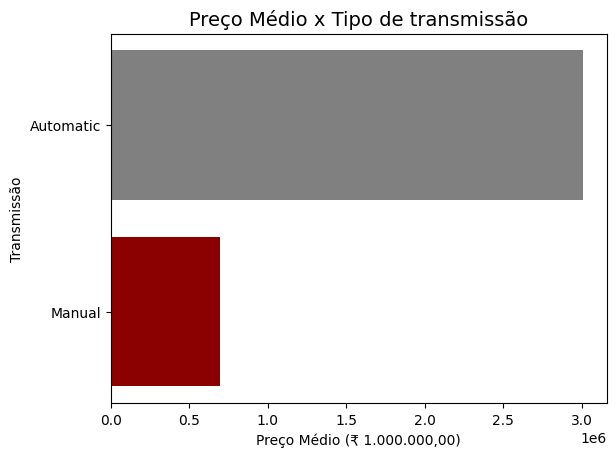

In [ ]:
# Definindo o preço médio de cada tipo de transmissão

preco_transmissao = a.groupby('Transmissão')['Preço'].mean().reset_index()
preco_transmissao.columns = ['Transmissão', 'Preço Médio']
preco_transmissao = preco_transmissao.sort_values(by='Preço Médio', ascending=True)

# Definindo o gráfico

plt.barh(preco_transmissao['Transmissão'], preco_transmissao['Preço Médio'], color=["darkred","grey"])
plt.xlabel('Preço Médio (₹ 1.000.000,00)')
plt.ylabel('Transmissão')
plt.title('Preço Médio x Tipo de transmissão', size=14)
plt.show()

In [ ]:
a.groupby('Transmissão')['Preço'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Transmissão,,,,,,,,
Automatic,793.00,"3,008,883.95","3,124,061.83","320,000.00","1,138,000.00","2,150,000.00","3,875,000.00","35,000,000.00"
Manual,986.00,"697,651.06","420,321.78","141,000.00","422,750.00","590,000.00","850,000.00","3,250,000.00"


Vemos uma clara diferença, em que carros automáticos apresentam preço médio bem acima de carros manuais.

Por último, vamos avaliar o preço médio para cada tipo de trem de força

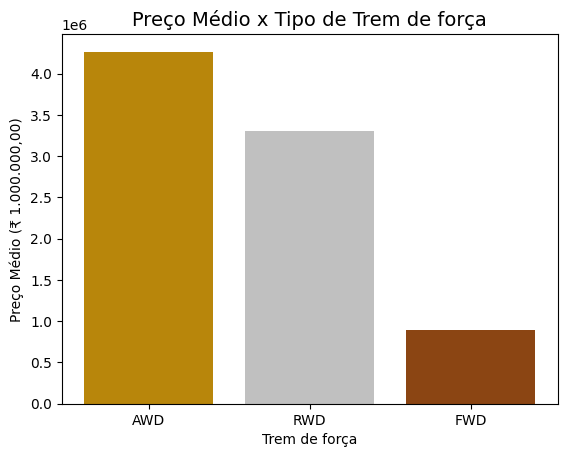

In [ ]:
# Definindo o preço médio de cada tipo de trem de força

preco_trem = a.groupby('Trem de força')['Preço'].mean().reset_index()
preco_trem.columns = ['Trem de força', 'Preço Médio']
preco_trem = preco_trem.sort_values(by='Preço Médio', ascending=False)

# Definindo o gráfico

plt.bar(preco_trem['Trem de força'], preco_trem['Preço Médio'], color=["darkgoldenrod","silver", "saddlebrown"])
plt.xlabel('Trem de força')
plt.ylabel('Preço Médio (₹ 1.000.000,00)')
plt.title('Preço Médio x Tipo de Trem de força', size=14)
plt.show()

In [ ]:
a.groupby('Trem de força')['Preço'].describe().sort_values(by='mean', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Trem de força,,,,,,,,
AWD,237.00,"4,267,059.06","3,491,868.56","625,000.00","1,875,000.00","3,450,000.00","5,500,000.00","27,500,000.00"
RWD,284.00,"3,304,123.20","3,552,484.33","240,000.00","1,337,500.00","2,412,500.00","4,175,000.00","35,000,000.00"
FWD,"1,258.00","893,692.31","742,727.55","141,000.00","450,000.00","650,000.00","1,050,000.00","6,000,000.00"


Vemos que o Trem de força do tipo AWD (motor fornece força de tração tanto para as rodas dianteiras como para as traseiras), apresenta maior preço médio do que RWD e FWD (que representam motor fornece força de tração apenas para as rodas traseiras e apenas para as dianteiras, respectivamente)

## **Modelagem dos dados**

Para a etapa da modelagem dos dados, vamos escolher técnicas de Machine Learning de regressão. Serão essas Regressão com regularização Ridge e Lasso, além da regressão XGBoost.

### Regressão Linear

Vamos começar transformando os valores categóricos em booleanos, utilizando a função get_dummies do pandas.

In [ ]:
colunas_categoricas = ['Fabricante', 'Combustível', 'Transmissão', 'Localização', 'Cor', 'Dono', 'Vendedor', 'Trem de força']
a = pd.get_dummies(a, columns=colunas_categoricas, drop_first=True)

Primeiramente, vamos gerar um modelo com padronização, utilizando a função StandardScaler.

In [ ]:
X = a.drop('Preço', axis=1)
y = a['Preço']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

padr = StandardScaler()
X_train_padr = pd.DataFrame(padr.fit_transform(X_train.to_numpy()), index=X_train.index, columns=X_train.columns)
X_test_padr = pd.DataFrame(padr.transform(X_test.to_numpy()), index=X_test.index, columns=X_test.columns)

#### Ridge

Agora, vamos iniciar gerando um modelo de regressão linear, sendo o modelo utilizado, gerado a partir da regularização Ridge. Para definir o melhor valor de 'alpha', vamos utilizar da validação cruzada:

In [ ]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X_train_padr, y_train)
best_alpha = ridge_cv.alpha_
print(f"Melhor alpha: {best_alpha}")

Melhor alpha: 0.0001


Definido o melhor alpha, vamos agora avaliar o desempenho do modelo de treinamento Ridge a partir de métricas R², Mean Squared Error (MSE) e Root Mean Squared Error (RMSE).

In [ ]:
y_train_pred = ridge_cv.predict(X_train_padr)
mse_ridge_train = mean_squared_error(y_train, y_train_pred)
r2_ridge_train = r2_score(y_train, y_train_pred)
rmse_ridge_train = mean_squared_error(y_train, y_train_pred, squared=False)

print(f"MSE Treinamento: {mse_ridge_train}")
print(f"R2 Treinamento: {r2_ridge_train}")
print(f"RMSE Treinamento: {rmse_ridge_train}")

MSE Treinamento: 1118904674952.7615
R2 Treinamento: 0.8114011521487167
RMSE Treinamento: 1057782.9053982492


Feita a avaliação do modelo de treinamento, utilizando os mesmos medidores de desempenho, vamos avaliar o modelo de teste.

In [ ]:
y_test_pred = ridge_cv.predict(X_test_padr)
mse_ridge_test = mean_squared_error(y_test, y_test_pred)
r2_ridge_test = r2_score(y_test, y_test_pred)
rmse_ridge_test = mean_squared_error(y_test, y_test_pred, squared=False)

print(f"MSE Teste: {mse_ridge_test}")
print(f"R2 Teste: {r2_ridge_test}")
print(f"RMSE Teste: {rmse_ridge_test}")

MSE Teste: 1164651364922.1443
R2 Teste: 0.7697812767144254
RMSE Teste: 1079190.1430805158


#### Lasso

Feita a análise para a regularização Ridge, vamos repetir o processo para o Lasso, utilizando novamente a validação cruzada para definir o melhor alpha para o modelo.

In [ ]:
# Definindo o melhor alpha

alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
lasso_cv = LassoCV(alphas=alphas, cv=5, random_state=42)
lasso_cv.fit(X_train_padr, y_train)
best_alpha = lasso_cv.alpha_
print(f"Melhor alpha: {best_alpha}")

# Avaliação do modelo com o melhor alpha

y_train_pred = lasso_cv.predict(X_train_padr)
mse = mean_squared_error(y_train, y_train_pred)
rmse = mean_squared_error(y_train, y_train_pred, squared=False)
r2 = r2_score(y_train, y_train_pred)

print(f"MSE Regressão Lasso: {mse}")
print(f"RMSE Regressão Lasso: {rmse}")
print(f"R2 Regressão Lasso: {r2}")

y_test_pred = lasso_cv.predict(X_test_padr)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = mean_squared_error(y_test, y_test_pred, squared=False)
r2_test = r2_score(y_test, y_test_pred)

print(f"MSE Teste Regressão Lasso: {mse_test}")
print(f"RMSE Teste Regressão Lasso: {rmse_test}")
print(f"R2 Teste Regressão Lasso: {r2_test}")

Melhor alpha: 1000.0
MSE Regressão Lasso: 1119693097571.4534
RMSE Regressão Lasso: 1058155.5167230635
R2 Regressão Lasso: 0.8112682582562933
MSE Teste Regressão Lasso: 1160968722163.0898
RMSE Teste Regressão Lasso: 1077482.5855498037
R2 Teste Regressão Lasso: 0.7705092313108322


Vemos que o modelo ainda apresenta um desempenho não muito satisfatório, apresentando um erro acima do esperado, e fazendo previsões distantes do que era esperado.

Para isso, vamos seguir com a modelagem dos dados, a fim de garantir que o modelo desenvolvido apresente um bom desempenho.

### XGBoost

Assim, vamos testar o desempenho do modelo XGBoost, a fim de encontrar o melhor modelo para rodar o nosso programa. Para isso vamos determinar os principais hiperparâmetros utilizando a biblioteca **hyperopt**.

Primeiramente, vamos definir os hiperparâmetros a serem escolhidos, de forma que o programa o **hyperopt** na função choice, escolha o melhor hiperparâmetro possível.

In [ ]:
param_grid = {'n_estimators': hp.choice('n_estimators', [100, 200, 300, 400, 500]),'learning_rate': hp.choice('learning_rate', [0.01, 0.05, 0.1, 0.2]),'max_depth': hp.choice('max_depth', [3, 4, 5, 6, 7, 8]),'subsample': hp.choice('subsample', [0.6, 0.7, 0.8, 0.9, 1.0]),'colsample_bytree': hp.choice('colsample_bytree', [0.6, 0.7, 0.8, 0.9, 1.0]),'gamma': hp.choice('gamma', [0, 0.1, 0.2, 0.3]),'reg_alpha': hp.choice('reg_alpha', [0, 0.01, 0.05, 0.1, 1]),'reg_lambda': hp.choice('reg_lambda', [0, 0.01, 0.05, 0.1, 1]),'objective': 'reg:squarederror','random_state': 42}


Agora, utilizando a função XGBRegressor, vamos definir uma função chamada objetivo, a qual tem o objetivo de determinar os hiperparâmetros que maximizem a métrica RMSE - Root Mean Squared Error.

In [ ]:
def objetivo(params):
    xgb_reg = xgb.XGBRegressor(**params)
    xgb_reg.fit(X_train_padr, y_train, eval_set=[(X_test_padr, y_test)], eval_metric="rmse", early_stopping_rounds=10, verbose=False)
    preds = xgb_reg.predict(X_test_padr)
    r2 = r2_score(y_test, preds)
    return {'loss': -r2, 'status': STATUS_OK}

Agora, vamos seguir, a partir da função objetivo determinada e com o uso das funções Trials e fmin da biblioteca **hyperopt**, para então determinar quais os melhores parâmetros.

In [ ]:
trials = Trials()
best = fmin(fn=objetivo, space=param_grid, algo=tpe.suggest, max_evals=100, trials=trials, rstate=np.random.default_rng(42))
best_params = {'n_estimators': [100, 200, 300, 400, 500][best['n_estimators']],'learning_rate': [0.01, 0.05, 0.1, 0.2][best['learning_rate']],'max_depth': [3, 4, 5, 6, 7, 8][best['max_depth']],'subsample': [0.6, 0.7, 0.8, 0.9, 1.0][best['subsample']],'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0][best['colsample_bytree']],'gamma': [0, 0.1, 0.2, 0.3][best['gamma']],'reg_alpha': [0, 0.01, 0.05, 0.1, 1][best['reg_alpha']],'reg_lambda': [0, 0.01, 0.05, 0.1, 1][best['reg_lambda']],'objetivo': 'reg:squarederror','random_state': 42}

print(f"Melhores parâmetros: {best_params}")

  1%|          | 1/100 [00:00<00:26,  3.78trial/s, best loss: -0.9141666250765361]

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(



  2%|▏         | 2/100 [00:00<00:35,  2.75trial/s, best loss: -0.9307760058321042]

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(



  3%|▎         | 3/100 [00:01<00:34,  2.81trial/s, best loss: -0.932133053474745] 

...

 97%|█████████▋| 97/100 [00:58<00:01,  1.52trial/s, best loss: -0.9385328159309487]

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(



 99%|█████████▉| 99/100 [00:59<00:00,  2.21trial/s, best loss: -0.9413597190135025]

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(



100%|██████████| 100/100 [00:59<00:00,  1.67trial/s, best loss: -0.9413597190135025]
Melhores parâmetros: {'n_estimators': 200, 'learning_rate': 0.1, 'max_depth': 7, 'subsample': 0.7, 'colsample_bytree': 0.8, 'gamma': 0.2, 'reg_alpha': 0.05, 'reg_lambda': 1, 'objetivo': 'reg:squarederror', 'random_state': 42}


Feito isso, temos o nosso modelo final, e assim, para concluir se seu desempenho é aceitável, vamos medir o desempenho dos modelos de teste e treinamento abaixo, a partir das métricas MSE, R² e RMSE.

In [ ]:
xgb_reg = xgb.XGBRegressor(**best_params)
xgb_reg.fit(X_train_padr, y_train, eval_set=[(X_train_padr, y_train), (X_test_padr, y_test)], eval_metric="rmse", early_stopping_rounds=10, verbose=True)

preds_test = xgb_reg.predict(X_test_padr)
mse = mean_squared_error(y_test, preds_test)
r2 = r2_score(y_test, preds_test)
rmse = mean_squared_error(y_test, preds_test, squared=False)

print(f"MSE Teste: {mse}")
print(f"R2 Teste: {r2}")
print(f"RMSE Teste: {rmse}")

preds_train = xgb_reg.predict(X_train_padr)
mse_train = mean_squared_error(y_train, preds_train)
r2_train = r2_score(y_train, preds_train)
rmse_train = mean_squared_error(y_train, preds_train, squared=False)

print(f"MSE Treinamento: {mse_train}")
print(f"R2 Treinamento: {r2_train}")
print(f"RMSE Treinamento: {rmse_train}")

[0]	validation_0-rmse:2245609.63589	validation_1-rmse:2083485.41504
[1]	validation_0-rmse:2101515.91971	validation_1-rmse:1945258.76075
[2]	validation_0-rmse:1945724.88952	validation_1-rmse:1830593.65976
[3]	validation_0-rmse:1804972.44857	validation_1-rmse:1699781.73343
[4]	validation_0-rmse:1670088.87096	validation_1-rmse:1588545.89534
[5]	validation_0-rmse:1567491.07803	validation_1-rmse:1475720.67757
[6]	validation_0-rmse:1456187.29047	validation_1-rmse:1375778.83698
[7]	validation_0-rmse:1368195.81173	validation_1-rmse:1313543.22470
[8]	validation_0-rmse:1286847.37565	validation_1-rmse:1244398.23531
[9]	validation_0-rmse:1207031.04523	validation_1-rmse:1172799.53936
[10]	validation_0-rmse:1124635.88414	validation_1-rmse:1092285.21766
[11]	validation_0-rmse:1054866.02337	validation_1-rmse:1047665.97085
[12]	validation_0-rmse:994567.01376	validation_1-rmse:1007154.25743
[13]	validation_0-rmse:928193.80578	validation_1-rmse:959672.41327
[14]	validation_0-rmse:864474.46169	validation_

/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `eval_metric` in `fit` method is deprecated for better compatibility with scikit-learn, use `eval_metric` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/sklearn.py:889: UserWarning: `early_stopping_rounds` in `fit` method is deprecated for better compatibility with scikit-learn, use `early_stopping_rounds` in constructor or`set_params` instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/xgboost/core.py:160: UserWarning: [22:59:35] WARNING: /workspace/src/learner.cc:742: 
Parameters: { "objetivo" } are not used.

  warnings.warn(smsg, UserWarning)


[24]	validation_0-rmse:531174.68481	validation_1-rmse:675824.09256
[25]	validation_0-rmse:506633.18554	validation_1-rmse:666522.37863
[26]	validation_0-rmse:483345.99477	validation_1-rmse:653057.24381
[27]	validation_0-rmse:463731.96510	validation_1-rmse:645829.82942
[28]	validation_0-rmse:447387.47266	validation_1-rmse:632688.73694
[29]	validation_0-rmse:437272.75485	validation_1-rmse:620844.50233
[30]	validation_0-rmse:420610.62784	validation_1-rmse:617195.99586
[31]	validation_0-rmse:405224.20004	validation_1-rmse:610717.07511
[32]	validation_0-rmse:391307.77419	validation_1-rmse:608054.25826
[33]	validation_0-rmse:385244.03467	validation_1-rmse:603427.27440
[34]	validation_0-rmse:369086.64596	validation_1-rmse:600797.14418
[35]	validation_0-rmse:360331.80055	validation_1-rmse:596342.54459
[36]	validation_0-rmse:352961.78813	validation_1-rmse:592787.80297
[37]	validation_0-rmse:345876.73701	validation_1-rmse:586421.42520
[38]	validation_0-rmse:332738.88294	validation_1-rmse:582045.0

O desempenho do modelo de treinamento e teste se mostrou bastante satisfatório. Por fim, vamos avaliar as variáveis preditoras mais importantes abaixo em uma tabela, com as 10 variáveis preditoras mais importantes.

In [ ]:
feature_importances = pd.DataFrame(xgb_reg.feature_importances_, index = X_train_padr.columns, columns=['importance']).sort_values('importance', ascending=False)
top_10 = feature_importances.head(10)
print("Importância das Features Selecionadas:")
print(top_10)

Importância das Features Selecionadas:
                       importance
Potência máxima (bhp)        0.28
Combustível_Diesel           0.15
Passageiros                  0.08
Torque máximo (Nm)           0.06
Tanque                       0.04
Altura                       0.04
Motor (cc)                   0.03
Largura                      0.03
Ano                          0.02
Combustível_Hybrid           0.02


Agora, vamos avaliá-las em um gráfico de colunas, para facilitar a visualização.

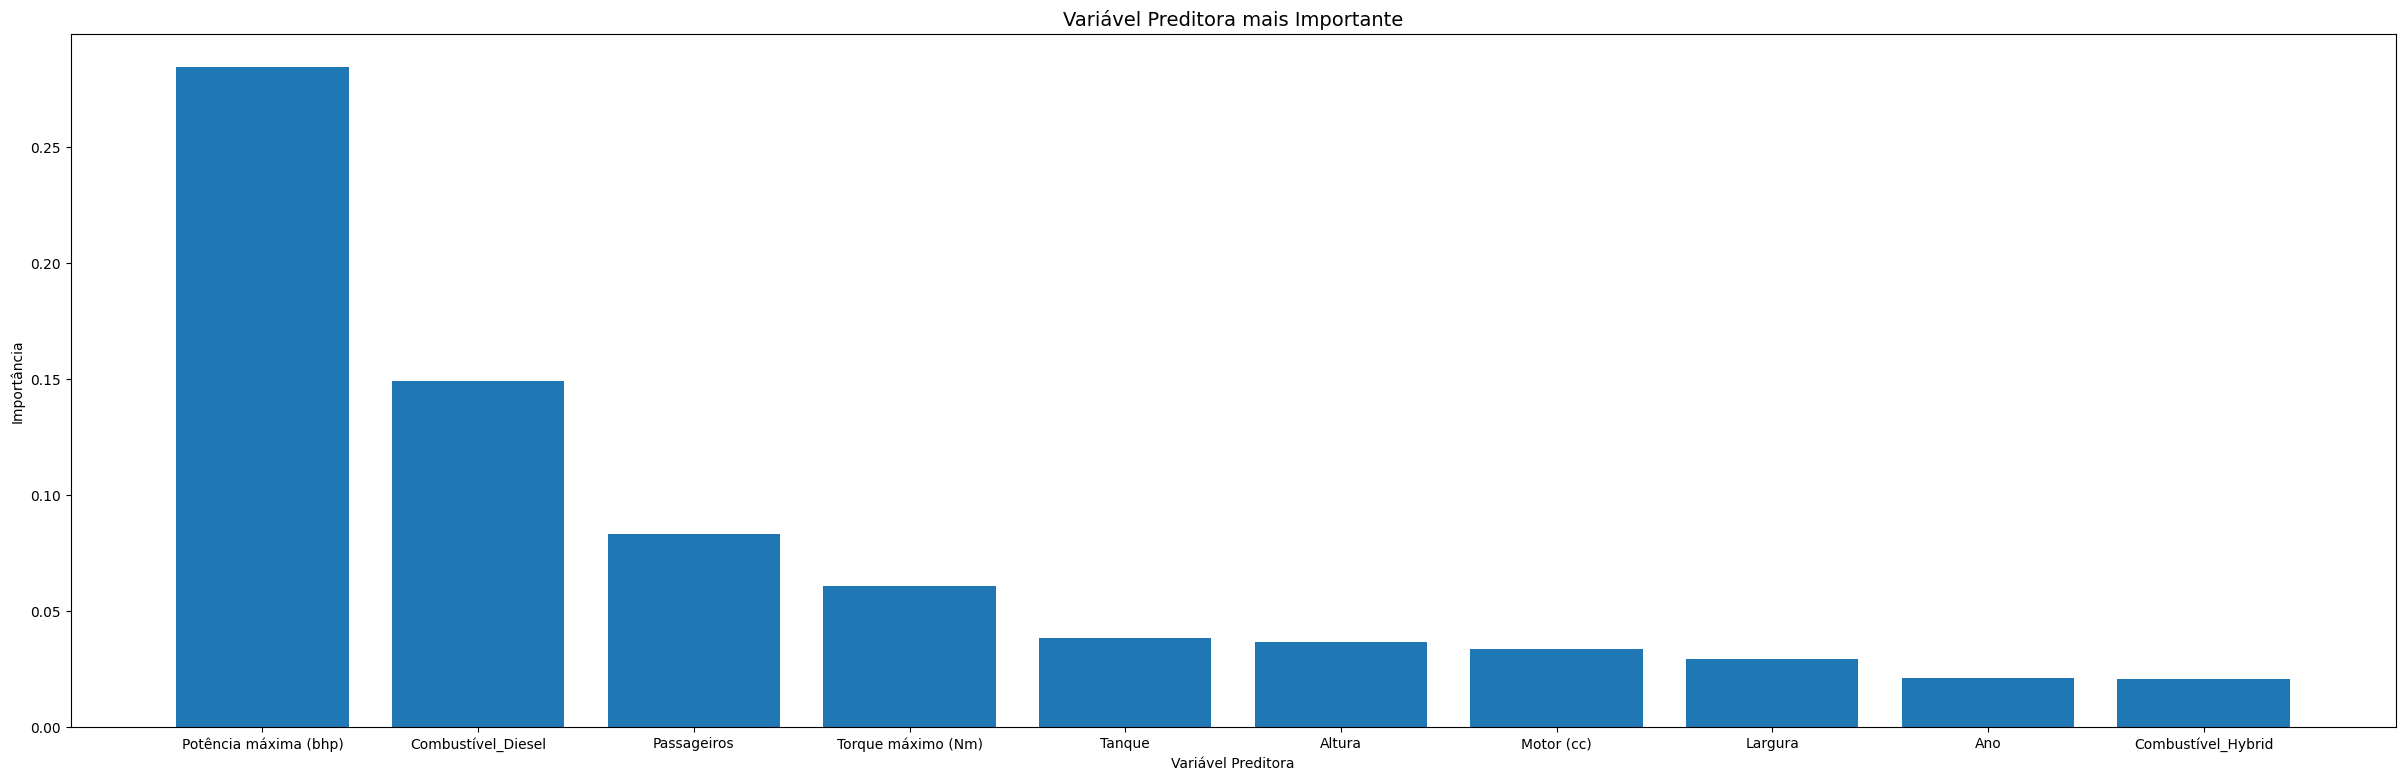

In [ ]:
plt.figure(figsize=(30, 9))
plt.bar(top_10.index, top_10['importance'])
plt.xlabel('Variável Preditora')
plt.ylabel('Importância')
plt.title('Variável Preditora mais Importante', size=14)
plt.show()

## **Conclusão**

A Conclusão final que podemos chegar é de que, com o desenvolvimento do modelo, como já havia sido previsto na análise exploratória dos dados, Potência máxima (bhp) é a variável preditora de maior importância. Isso faz sentido já que carros mais potentes tendem a ser mais rápidos, além de terem motores mais sofisticados, melhor desempenho, potência e eficiência.

Outros parâmetros como Torque máximo (Nm), Capacidade do Tanque, Altura, Ano,
Largura e Número de passageiros apresentam boa influência.
Isso significa que carros maiores e mais novos tendem a ser mais caros, o que também faz total sentido.
Além do fato de Potência máxima (bhp) e Torque máximo (Nm) evidenciarem que carros com melhor desempenho, motor e potência tendem a ser mais caros, o que faz total sentido.

Com relação a parâmetros categóricos, o que mais apresenta influência no preço é de carros movidos a Diesel, o que é interessante de se observar, já que na análise exploratória, carros híbridos apresentavam maior preço médio. Porém, o fato de existirem apenas 3 carros híbridos enquanto existiam 918 a Diesel, pode justificar que o carro ser movido a Diesel seja uma variável preditora mais influente, visto que mesmo se apresentando predominante ao longo da base, conseguiu apresentar um preço médio bem superior a carros movidos aos demais tipos de combustível (exceto híbridos).

Por fim, após desenvolvimento e análise do modelo, é possível concluir que seu desempenho é satisfatório, sendo portanto, bem sucedido.